## Comment installer des bibliothèques Python dans Colab

Pour installer des bibliothèques Python dans Google Colab (ou tout autre environnement Python), vous utilisez généralement le gestionnaire de paquets `pip`.

Dans un notebook Colab, vous devez préfixer la commande `pip` avec un point d'exclamation (`!`) pour l'exécuter comme une commande shell.

In [ ]:
# Exemple d'installation d'une bibliothèque (par exemple, scikit-learn si elle n'était pas déjà installée)
!pip install scikit-learn

# Vous pouvez également spécifier une version spécifique
# !pip install pandas==1.5.3

# Pour mettre à jour une bibliothèque existante
# !pip install --upgrade numpy

print("La commande `!pip install` est utilisée pour installer des bibliothèques.")

EXERCISES 1: Détection et suppression des doublons

In [15]:
import pandas as pd
import seaborn as sns
# 1. Charger le dataset Titanic
df = sns.load_dataset('titanic')
# 2. Identifier les doublons
masque_doublons = df.duplicated()        # Série True/False pour chaque ligne
nb_doublons = masque_doublons.sum()      # Compter les doublons
print(f"Doublons trouvés : {nb_doublons}")

# Afficher les lignes dupliquées
print(df[masque_doublons])

# 3. Supprimer les doublons
df_clean = df.drop_duplicates()

# 4. Vérification
print(f"Avant : {len(df)} lignes")
print(f"Après : {len(df_clean)} lignes")
print(f"Supprimées : {len(df) - len(df_clean)}")
print(f"Doublons restants : {df_clean.duplicated().sum()}")


Doublons trouvés : 107
     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
47          1       3  female   NaN      0      0   7.7500        Q   Third   
76          0       3    male   NaN      0      0   7.8958        S   Third   
77          0       3    male   NaN      0      0   8.0500        S   Third   
87          0       3    male   NaN      0      0   8.0500        S   Third   
95          0       3    male   NaN      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
870         0       3    male  26.0      0      0   7.8958        S   Third   
877         0       3    male  19.0      0      0   7.8958        S   Third   
878         0       3    male   NaN      0      0   7.8958        S   Third   
884         0       3    male  25.0      0      0   7.0500        S   Third   
886         0       2    male  27.0      0      0  13.0000        S  Second   

       who  adult_male deck 

Exercice 5

In [151]:
# ======================================================
# Exercice 5: Standardisation et normalisation des données (sur df_encoded)
# ======================================================

df_scaled = df_encoded.copy()

# Identify numerical columns for scaling
# Exclude 'survived', 'is_alone', 'Title_encoded' if they are already 0/1 or encoded
numerical_cols_for_scaling = df_scaled.select_dtypes(include=['number']).columns.tolist()

# Remove target variable and already encoded binary features
if 'survived' in numerical_cols_for_scaling:
    numerical_cols_for_scaling.remove('survived')
if 'is_alone' in numerical_cols_for_scaling:
    numerical_cols_for_scaling.remove('is_alone')

# Drop any original categorical columns that were kept and should not be scaled
# (e.g., 'pclass' is often treated as categorical but is numeric in dataset)
# For simplicity, we'll scale all remaining numerical columns after exclusions.


# Apply StandardScaler to selected numerical columns
scaler = StandardScaler()
df_scaled[numerical_cols_for_scaling] = scaler.fit_transform(df_scaled[numerical_cols_for_scaling])

print("DataFrame after Scaling:")
display(df_scaled.head())
print(df_scaled.info())

DataFrame after Scaling:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,FamilySize,sex_encoded,alone_encoded,adult_male_encoded,alive_encoded
0,0,0.827377,male,-0.592481,0.432793,-0.473674,-0.502445,S,Third,man,True,Unknown,Southampton,no,False,0.059160,0.737695,-1.231645,0.811922,-0.789272
1,1,-1.566107,female,0.638789,0.432793,-0.473674,0.786845,C,First,woman,False,C,Cherbourg,yes,False,0.059160,-1.355574,-1.231645,-1.231645,1.266990
2,1,0.827377,female,-0.284663,-0.474545,-0.473674,-0.488854,S,Third,woman,False,Unknown,Southampton,yes,True,-0.560975,-1.355574,0.811922,-1.231645,1.266990
3,1,-1.566107,female,0.407926,0.432793,-0.473674,0.420730,S,First,woman,False,C,Southampton,yes,False,0.059160,-1.355574,-1.231645,-1.231645,1.266990
4,0,0.827377,male,0.407926,-0.474545,-0.473674,-0.486337,S,Third,man,True,Unknown,Southampton,no,True,-0.560975,0.737695,0.811922,0.811922,-0.789272


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   survived            891 non-null    int64   
 1   pclass              891 non-null    float64 
 2   sex                 891 non-null    object  
 3   age                 891 non-null    float64 
 4   sibsp               891 non-null    float64 
 5   parch               891 non-null    float64 
 6   fare                891 non-null    float64 
 7   embarked            891 non-null    object  
 8   class               891 non-null    category
 9   who                 891 non-null    object  
 10  adult_male          891 non-null    bool    
 11  deck                891 non-null    object  
 12  embark_town         891 non-null    object  
 13  alive               891 non-null    object  
 14  alone               891 non-null    bool    
 15  FamilySize          891 non-null    floa


Exercice 6 : Encodage des caractéristiques

In [154]:
import pandas as pd

# Remplacez 'Chemin/vers/votre/fichier.csv' par le chemin réel de votre fichier sur Google Drive
file_path = '/content/drive/MyDrive/votre_fichier.csv'

try:
    df_from_drive = pd.read_csv(file_path)
    print(f"Fichier '{file_path}' chargé avec succès.")
    display(df_from_drive.head())
except FileNotFoundError:
    print(f"Erreur: Le fichier '{file_path}' n'a pas été trouvé. Veuillez vérifier le chemin.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier: {e}")

Erreur: Le fichier '/content/drive/MyDrive/votre_fichier.csv' n'a pas été trouvé. Veuillez vérifier le chemin.


### 1. Identification des valeurs manquantes

In [91]:
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
import numpy as np

# Chargement du dataset Titanic
df = sns.load_dataset('titanic')

# Identification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nPourcentage de valeurs manquantes :")
print(round(df.isnull().mean() * 100, 2))

Valeurs manquantes par colonne :
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Pourcentage de valeurs manquantes :
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


In [92]:
# Suppression des lignes où il y a des NaN dans 'embarked'
df_drop_embarked = df.dropna(subset=['embarked'])

# Suppression des lignes avec au moins une valeur manquante (très agressif)
df_drop_all = df.dropna()

print(f"Shape original : {df.shape}")
print(f"Après drop embarked : {df_drop_embarked.shape}")
print(f"Après dropna complet : {df_drop_all.shape}")

Shape original : (891, 15)
Après drop embarked : (889, 15)
Après dropna complet : (182, 15)


In [96]:
# Imputation de l'âge en fonction de la classe et du sexe (plus précis)
def impute_age(row):
    if pd.isnull(row['age']):
        # Médiane par Pclass et sex
        median_age = df.groupby(['pclass', 'sex'])['age'].median()
        return median_age[row['pclass'], row['sex']]
    else:
        return row['age']

df_advanced = df.copy()
df_advanced['age'] = df_advanced.apply(impute_age, axis=1)

print("Valeurs manquantes dans 'age' après imputation avancée :", df_advanced['age'].isnull().sum())

Valeurs manquantes dans 'age' après imputation avancée : 0


In [129]:
# Colonnes numériques à mettre à l'échelle
numerical_cols = ['age', 'fare', 'family_size', 'sibsp', 'parch']

# On garde une copie pour comparer avant/après
df_scaled = df_final.copy()

In [131]:
# ------------------- StandardScaler (recommandé pour la plupart des modèles) -------------------
std_scaler = StandardScaler()

df_scaled[['age_std', 'fare_std', 'family_size_std']] = std_scaler.fit_transform(
    df_scaled[['age', 'fare', 'family_size']]
)

# ------------------- MinMaxScaler (utile pour fare et family_size) -------------------
minmax_scaler = MinMaxScaler()

df_scaled[['fare_minmax', 'family_size_minmax']] = minmax_scaler.fit_transform(
    df_scaled[['fare', 'family_size']]
)

print(" Scaling terminé !")

 Scaling terminé !


In [143]:
# Comparaison avant / après scaling
print("\n=== Statistiques avant et après scaling ===")
cols_to_compare = ['age', 'fare', 'family_size']

for col in cols_to_compare:
    print(f"\n{col.upper():15} | Mean: {df_final[col].mean():.3f} | Std: {df_final[col].std():.3f}")
    print(f"{'After Standard':15} | Mean: {df_scaled[col+'_std'].mean():.3f} | Std: {df_scaled[col+'_std'].std():.3f}")


=== Statistiques avant et après scaling ===

AGE             | Mean: 29.699 | Std: 14.526
After Standard  | Mean: 0.000 | Std: 1.001

FARE            | Mean: 32.204 | Std: 49.693
After Standard  | Mean: 0.000 | Std: 1.001

FAMILY_SIZE     | Mean: 1.905 | Std: 1.613
After Standard  | Mean: -0.000 | Std: 1.001


Exercice 7 : Transformation des données pour la caractéristique Âge

In [165]:
import pandas as pd

# ======================
# 1. Création des groupes d'âge avec pd.cut()
# ======================

# Définition des bornes et des étiquettes
bins = [0, 12, 18, 60, 100]
labels = ['Enfant', 'Adolescent', 'Adulte', 'Senior']

# Création de la nouvelle colonne catégorielle
df['Groupe_Age'] = pd.cut(df['age'],
                          bins=bins,
                          labels=labels,
                          right=False,      # [0,12) , [12,18), etc.
                          include_lowest=True)

# Vérification
print(df[['age', 'Groupe_Age']].head(10))
print("\nDistribution des groupes d'âge :")
print(df['Groupe_Age'].value_counts().sort_index())

    age  Groupe_Age
0  22.0      Adulte
1  38.0      Adulte
2  26.0      Adulte
3  35.0      Adulte
4  35.0      Adulte
5   NaN         NaN
6  54.0      Adulte
7   2.0      Enfant
8  27.0      Adulte
9  14.0  Adolescent

Distribution des groupes d'âge :
Groupe_Age
Enfant         68
Adolescent     45
Adulte        575
Senior         26
Name: count, dtype: int64


In [166]:
# ======================
# 2. Encodage One-Hot
# ======================

# Application de get_dummies
df_encoded = pd.get_dummies(df,
                            columns=['Groupe_Age'],
                            prefix='Age',
                            prefix_sep='_')

# Affichage des nouvelles colonnes créées
print("Colonnes après encodage one-hot :")
print([col for col in df_encoded.columns if col.startswith('Age_')])

Colonnes après encodage one-hot :
['Age_Enfant', 'Age_Adolescent', 'Age_Adulte', 'Age_Senior']


In [168]:
import pandas as pd

# Création des groupes d'âge
bins = [0, 12, 18, 60, 100]
labels = ['Enfant', 'Adolescent', 'Adulte', 'Senior']

df['Groupe_Age'] = pd.cut(df['age'],
                          bins=bins,
                          labels=labels,
                          right=False,
                          include_lowest=True)

# Encodage One-Hot
df = pd.get_dummies(df,
                    columns=['Groupe_Age'],
                    prefix='Age',
                    dtype=int)   # dtype=int pour avoir 0/1 au lieu de True/False

# Résultat
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  Age_Enfant  \
0    man        True  NaN  Southampton    no  False           0   
1  woman       False    C    Cherbourg   yes  False           0   
2  woman       False  NaN  Southampton   yes   True           0   
3  woman       False    C  Southampton   yes  False           0   
4    man        True  NaN  Southampton    no   True           0   

   Age_Adolescent  Age_Adulte  Age_Senior  
0               0           1           0  
1               0           1           0  
2       

Exercice 4 : Détection et traitement des valeurs aberrantes

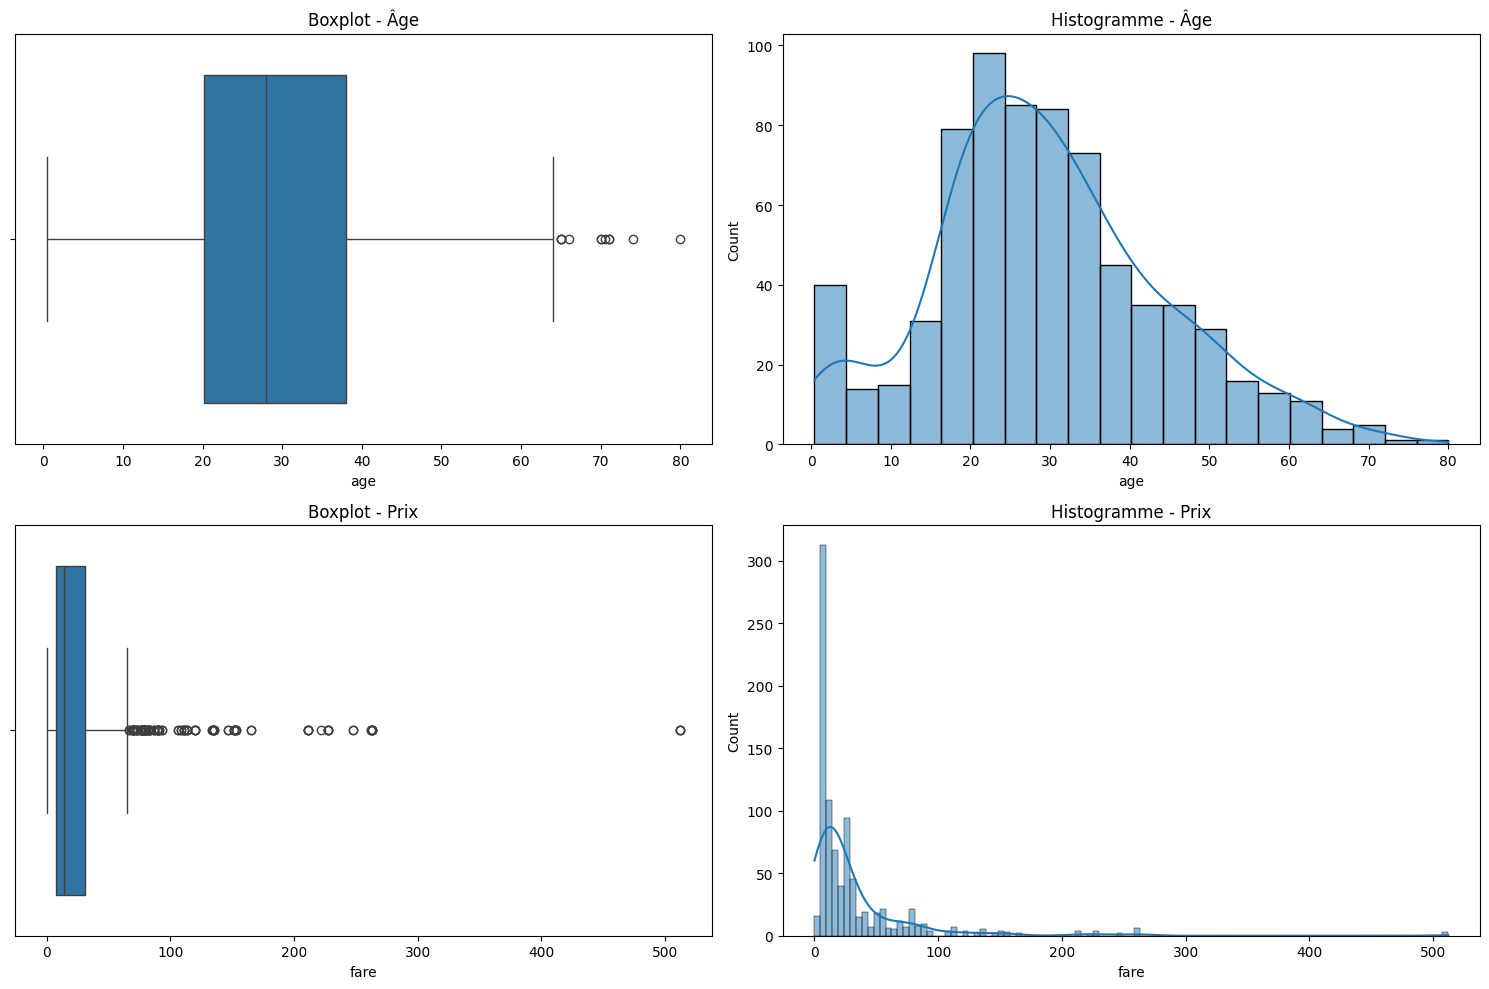

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. Visualisation des distributions
# ======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Âge
sns.boxplot(x=df['age'], ax=axes[0,0])
axes[0,0].set_title('Boxplot - Âge')

sns.histplot(df['age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Histogramme - Âge')

# Prix
sns.boxplot(x=df['fare'], ax=axes[1,0])
axes[1,0].set_title('Boxplot - Prix')

sns.histplot(df['fare'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Histogramme - Prix')

plt.tight_layout()
plt.show()

In [172]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    print(f"\n{'='*50}")
    print(f"Analyse des outliers - {column}")
    print(f"{'='*50}")
    print(f"Q1 (25%)     : {Q1:.2f}")
    print(f"Q3 (75%)     : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Borne inférieure : {lower_bound:.2f}")
    print(f"Borne supérieure : {upper_bound:.2f}")
    print(f"Nombre d'outliers : {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)者に教えてください")

    return lower_bound, upper_bound

# Application
lower_age, upper_age = detect_outliers_iqr(df, 'age')
lower_price, upper_price = detect_outliers_iqr(df, 'fare')


Analyse des outliers - age
Q1 (25%)     : 20.12
Q3 (75%)     : 38.00
IQR          : 17.88
Borne inférieure : -6.69
Borne supérieure : 64.81
Nombre d'outliers : 11 (1.23%)者に教えてください

Analyse des outliers - fare
Q1 (25%)     : 7.91
Q3 (75%)     : 31.00
IQR          : 23.09
Borne inférieure : -26.72
Borne supérieure : 65.63
Nombre d'outliers : 116 (13.02%)者に教えてください


In [175]:
# Création d'une copie pour comparer
df_clean = df.copy()

# ======================
# Plafonnement à 98% (recommandé)
# ======================

# Pour l'Âge
df_clean['age'] = df_clean['age'].clip(
    lower=df['age'].quantile(0.01),
    upper=df['age'].quantile(0.98)
)

# Pour le Prix
df_clean['fare'] = df_clean['fare'].clip(
    lower=df['fare'].quantile(0.01),
    upper=df['fare'].quantile(0.98)
)

print("✅ Traitement par plafonnement (1% - 98%) effectué")

✅ Traitement par plafonnement (1% - 98%) effectué


In [177]:
# ======================
# Comparaison statistique
# ======================

comparison = pd.DataFrame({
    'Statistique': ['Min', 'Max', 'Mean', 'Std', 'Outliers IQR'],
    'Âge_Original': [
        df['age'].min(), df['age'].max(),
        df['age'].mean(), df['age'].std(),
        len(df[(df['age'] < lower_age) | (df['age'] > upper_age)])
    ],
    'Âge_Traité': [
        df_clean['age'].min(), df_clean['age'].max(),
        df_clean['age'].mean(), df_clean['age'].std(),
        len(df_clean[(df_clean['age'] < lower_age) | (df_clean['age'] > upper_age)])
    ],
    'Prix_Original': [
        df['fare'].min(), df['fare'].max(),
        df['fare'].mean(), df['fare'].std(),
        len(df[(df['fare'] < lower_price) | (df['fare'] > upper_price)])
    ],
    'Prix_Traité': [
        df_clean['fare'].min(), df_clean['fare'].max(),
        df_clean['fare'].mean(), df_clean['fare'].std(),
        len(df_clean[(df_clean['fare'] < lower_price) | (df_clean['fare'] > upper_price)])
    ]
})

print(comparison.round(2))

    Statistique  Âge_Original  Âge_Traité  Prix_Original  Prix_Traité
0           Min          0.42        1.00           0.00         0.00
1           Max         80.00       62.74         512.33       211.34
2          Mean         29.70       29.59          32.20        30.68
3           Std         14.53       14.22          49.69        39.90
4  Outliers IQR         11.00        0.00         116.00       116.00


Exercice 3 : Ingénierie des fonctionnalités

In [10]:
import pandas as pd
import re
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ============================
# 1. Chargement des données
# ============================
# Charger le dataset Titanic depuis seaborn
df = sns.load_dataset('titanic')

print("Shape initial :", df.shape)
print(df.columns.tolist())

Shape initial : (891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [12]:
# =========================================
# 2.1 Family Size = sibsp + parch + 1 (soi-même)
# =========================================
df['Family_Size'] = df['sibsp'] + df['parch'] + 1

# Optionnel : catégorie de taille de famille
df['Family_Size_Category'] = pd.cut(df['Family_Size'],
                                    bins=[0, 1, 4, 7, 20],
                                    labels=['Alone', 'Small', 'Medium', 'Large'])

In [25]:
import pandas as pd
import re

# Data is already loaded in cell f-ndG8ikAgFl

# Feature Engineering
df['Family_Size'] = df['sibsp'] + df['parch'] + 1

def extract_title(name_val):
    title = re.search(r',\s*([^\.]+)\.', name_val)
    if title:
        title = title.group(1).strip()
        title_mapping = {
            'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
            'Lady': 'Lady', 'Countess': 'Lady', 'Dona': 'Lady',
            'Don': 'Noble', 'Sir': 'Noble', 'Jonkheer': 'Noble',
            'Major': 'Noble', 'Col': 'Noble', 'Capt': 'Noble',
            'Rev': 'Rev', 'Dr': 'Dr'
        }
        return title_mapping.get(title, title)
    return 'Unknown'

columns_to_encode = ['sex', 'embarked']

if 'name' in df.columns:
    df['Title'] = df['name'].apply(extract_title)
    columns_to_encode.append('Title')
    print("✅ 'Title' feature extracted from 'name' column.")
else:
    print("⚠️ 'name' column not found in DataFrame. Skipping 'Title' feature extraction.")

# Encodage One-Hot
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

print("✅ Feature Engineering terminé !")
print("Nouvelles colonnes créées :", [col for col in df.columns if col not in
                                      ['PassengerId', 'Survived', 'name', 'Ticket', 'Cabin']])


⚠️ 'name' column not found in DataFrame. Skipping 'Title' feature extraction.
✅ Feature Engineering terminé !
Nouvelles colonnes créées : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'Family_Size', 'Family_Size_Category', 'sex_male', 'embarked_Q', 'embarked_S']


In [28]:
import re
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Création de la caractéristique 'FamilySize'
# Formule : Nombre de frères/sœurs/époux (sibsp) + parents/enfants (parch) + 1 (la personne elle-même)
df["FamilySize"] = df["sibsp"] + df["parch"] + 1


# 2. Extraction du titre depuis la colonne 'name'
def extract_title(name_val):
    # Recherche un mot qui se termine par un point (ex: Mr., Miss.)
    title_search = re.search(r" ([A-Za-z]+)\.", name_val)
    if title_search:
        return title_search.group(1)
    return ""


# Application de la fonction pour créer la colonne 'Title'
if 'name' in df.columns:
    df["Title"] = df["name"].apply(extract_title)

    # Optionnel : Regroupement des titres rares pour éviter le surapprentissage
    title_counts = df["Title"].value_counts()
    rare_titles = title_counts[title_counts < 10].index
    df["Title"] = df["Title"].replace(rare_titles, "Rare")

    # 3. Encodage One-Hot de la nouvelle variable 'Title'
    # On utilise sparse_output=False pour obtenir directement un tableau NumPy dense
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    # Ajustement et transformation de la colonne Title
    title_encoded = encoder.fit_transform(df[["Title"]])

    # Création d'un DataFrame avec les nouvelles colonnes encodées
    encoded_cols = encoder.get_feature_names_out(["Title"])
    df_encoded_titles = pd.DataFrame(
        title_encoded, columns=encoded_cols, index=df.index
    )

    # Fusion avec le DataFrame principal et suppression de l'ancienne colonne textuelle
    df = pd.concat([df, df_encoded_titles], axis=1)
    df = df.drop(columns=["Title"])

    # Affichage du résultat
    print(df[["FamilySize"] + list(encoded_cols)].head())
else:
    print("⚠️ 'name' column not found in DataFrame. Skipping 'Title' feature extraction and One-Hot Encoding.")
    # Affichage du résultat pour FamilySize only if Title was not extracted
    print(df[["FamilySize"]].head())

⚠️ 'name' column not found in DataFrame. Skipping 'Title' feature extraction and One-Hot Encoding.
   FamilySize
0           2
1           2
2           1
3           2
4           1


Exercice 2 : Gestion des valeurs manquantes

In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
import seaborn as sns # Import seaborn to load the dataset

# ==========================================
# CHARGEMENT DU JEU DE DONNÉES
# ==========================================
# Chargement initial du fichier titanic depuis seaborn
df = sns.load_dataset("titanic")
print(f"Format initial du dataset : {df.shape}")

# ==========================================
# 🌟 EXERCICE 1 : GESTION DES DOUBLONS
# ==========================================
# Choix : Vérification sur l'intégralité des colonnes pour identifier de vrais doublons de saisie
rows_before = df.shape[0]
duplicate_count = df.duplicated().sum()

# Suppression uniquement si des doublons existent
if duplicate_count > 0:
    df = df.drop_duplicates()

rows_after = df.shape[0]
print(f"Exercice 1 - Doublons supprimés : {duplicate_count}")
print(f"Lignes avant : {rows_before} | Lignes après : {rows_after}\n")

# ==========================================
# 🌟 EXERCICE 2 & 3 : VALEURS MANQUANTES & INGÉNIERIE (AMONT)
# ==========================================
# Choix méthodologique : Créer les nouvelles variables AVANT de supprimer ou modifier radicalement les colonnes mères.

# 1. Feature Engineering (Exercice 3 - Partie 1)
# FamilySize : regroupe les membres de la famille + le passager lui-même
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

# Extraction du Titre depuis le Nom (Ex: Mr, Miss, Master)
# Ensure 'name' column exists before trying to extract title
if 'name' in df.columns:
    df["Title"] = df["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    # Regroupement des titres rares pour éviter le surapprentissage (bruit statistique)
    rare_titles = df["Title"].value_counts()[df["Title"].value_counts() < 10].index
    df["Title"] = df["Title"].replace(rare_titles, "Rare")
else:
    df["Title"] = 'Unknown' # Assign a default if 'name' is missing
    print("Warning: 'name' column not found, 'Title' feature set to 'Unknown'.")

# Création d'une variable binaire pour la présence d'une cabine (l'absence de cabine indique souvent un billet de basse classe)
# Corrected column name from 'Cabin' to 'deck'
df["Has_Cabin"] = df["deck"].notna().astype(int)

# 2. Imputation des valeurs manquantes (Exercice 2)
# Colonne 'deck' : Plus de 70% de valeurs manquantes, la colonne d'origine est supprimée car "Has_Cabin" capture déjà l'essentiel du signal
# Corrected column name from 'Cabin' to 'deck'
df = df.drop(columns=["deck"], errors='ignore') # Use errors='ignore' if 'deck' might already be dropped

# Colonne 'embarked' : Seulement 2 valeurs manquantes. Imputation par le Mode (la valeur la plus fréquente)
# Corrected column name from 'Embarked' to 'embarked'
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Colonne 'age' : ~20% de manquants. Imputation fine par la Médiane calculée par sous-groupes (Classe x Sexe)
# Corrected column names from 'Age', 'Pclass', 'Sex' to 'age', 'pclass', 'sex'
df["age"] = df["age"].fillna(df.groupby(["pclass", "sex"])["age"].transform("median"))

print("Exercice 2 & 3 - Valeurs manquantes après traitement :")
print(f"{df[['age', 'embarked', 'Has_Cabin']].isnull().sum()}\n")

# ==========================================
# 🌟 EXERCICE 4 : TRAITEMENT DES VALEURS ABERRANTES (OUTLIERS)
# ==========================================
# Choix : Utilisation de la méthode de l'Écart Interquartile (IQR) pour la colonne 'fare' (Prix du billet).
# La colonne 'fare' présente une forte asymétrie à droite (quelques billets à des prix extrêmement élevés).

# Corrected column name from 'Fare' to 'fare'
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

# Définition des barres techniques d'outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Choix de traitement : Plafonnement (Capping) au quantile 0.98 pour limiter l'impact des valeurs extrêmes sans perdre de lignes
# Corrected column name from 'Fare' to 'fare'
fare_98th = df["fare"].quantile(0.98)
df["fare"] = np.where(df["fare"] > fare_98th, fare_98th, df["fare"])
print(
    f"Exercice 4 - Plafonnement de 'fare' au 98ème quantile ({fare_98th:.2f})\n"
)

# ==========================================
# 🌟 EXERCICE 5 : STANDARDISATION ET NORMALISATION
# ==========================================
# Choix méthodologique :
# - StandardScaler pour 'age' car sa distribution après imputation se rapproche d'une courbe normale.
# - MinMaxScaler pour 'fare' et 'FamilySize' car ces distributions restent asymétriques ou strictement bornées.

scaler_std = StandardScaler()
# Corrected column name from 'Age' to 'age'
df["age_scaled"] = scaler_std.fit_transform(df[["age"]])

scaler_minmax = MinMaxScaler()
# Corrected column name from 'Fare' to 'fare'
df["fare_scaled"] = scaler_minmax.fit_transform(df[["fare"]])
# 'FamilySize' is already correct (if created)
df["FamilySize_scaled"] = scaler_minmax.fit_transform(df[["FamilySize"]])

print("Exercice 5 - Variables numériques mises à l'échelle (Aperçu) :")
print(df[["age_scaled", "fare_scaled", "FamilySize_scaled"]].head(), "\n")

# ==========================================
# 🌟 EXERCICE 6 : ENCODAGE DES CARACTÉRISTIQUES CATÉGORIELLES
# ==========================================
# Choix : Encodage One-Hot pour les variables nominales non ordonnées ('sex', 'embarked', 'Title')
# On utilise drop='first' pour éviter le piège de la colinéarité (Dummy Variable Trap)

categorical_cols = [col for col in ["sex", "embarked", "Title"] if col in df.columns]
encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded_features = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index,
)

# Fusion avec le dataset principal
df = pd.concat([df, encoded_df], axis=1)
print(f"Exercice 6 - Colonnes après encodage One-Hot de {categorical_cols} :")
print(encoded_df.columns.tolist(), "\n")

# ==========================================
# 🌟 EXERCICE 7 : TRANSFORMATION DE LA CARACTÉRISTIQUE ÂGE
# ==========================================
# Choix : Création de tranches d'âge basées sur les grandes étapes biologiques et sociales de la vie.
age_bins = [0, 12, 18, 60, 100]
age_labels = ["Enfant", "Adolescent", "Adulte", "Senior"]

# Découpage en catégories
# Corrected column name from 'Age' to 'age'
df["AgeGroup"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# Encodage des groupes créés (pd.get_dummies convient ici pour une analyse rapide)
age_group_dummies = pd.get_dummies(
    df["AgeGroup"], prefix="AgeGroup", dtype=int
)
df = pd.concat([df, age_group_dummies], axis=1)

print("Exercice 7 - Création et encodage des groupes d'âge terminé !")
# Corrected column name from 'Age' to 'age'
print(df[["age", "AgeGroup"] + age_group_dummies.columns.tolist()].head())

# Nettoyage final : Suppression des colonnes textuelles d'origine non exploitables par un modèle
columns_to_drop = [
    "passengerid",
    "name",
    "sex",
    "ticket",
    "embarked",
    "Title", # Only drop if it was created
    "AgeGroup",
    "age",
    "fare",
    "FamilySize",
    "deck" # 'deck' was dropped earlier, but ensure it's not a problem if it wasn't
]
df_final = df.drop(columns=columns_to_drop, errors="ignore")
print(f"\nFinalisation - Dimensions du dataset prêt pour le ML : {df_final.shape}")

Format initial du dataset : (891, 15)
Exercice 1 - Doublons supprimés : 107
Lignes avant : 891 | Lignes après : 784

Exercice 2 & 3 - Valeurs manquantes après traitement :
age          0
embarked     0
Has_Cabin    0
dtype: int64

Exercice 4 - Plafonnement de 'fare' au 98ème quantile (214.99)

Exercice 5 - Variables numériques mises à l'échelle (Aperçu) :
   age_scaled  fare_scaled  FamilySize_scaled
0   -0.548295     0.033722                0.1
1    0.599266     0.331558                0.1
2   -0.261405     0.036861                0.0
3    0.384098     0.246983                0.1
4    0.384098     0.037443                0.0 

Exercice 6 - Colonnes après encodage One-Hot de ['sex', 'embarked', 'Title'] :
['sex_male', 'embarked_Q', 'embarked_S'] 

Exercice 7 - Création et encodage des groupes d'âge terminé !
    age AgeGroup  AgeGroup_Enfant  AgeGroup_Adolescent  AgeGroup_Adulte  \
0  22.0   Adulte                0                    0                1   
1  38.0   Adulte              